In [144]:
%pip install openai pandas scikit-learn matplotlib tqdm
from openai import OpenAI
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [145]:
from openai import OpenAI

BASE_URL = "http://210.109.80.47:29091/v1"
MODEL = "google/gemma-4-E4B-it"

client = OpenAI(base_url=BASE_URL, api_key="EMPTY")  # no key needed

resp = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Say hello in one word."}],
    max_tokens=20,
)

print(resp.choices[0].message.content)  # the generated text
print(resp.usage) 

Hello
CompletionUsage(completion_tokens=2, prompt_tokens=15, total_tokens=17, completion_tokens_details=None, prompt_tokens_details=None)


In [146]:
df = pd.read_csv("data/emergency_triage_clean.csv", sep=',', decimal=".",encoding="utf-8-sig")


cols = ["BT", "HR", "RR", "SpO2",
        "SBP", "DBP", "NRS_pain", "Chief_complaint", "Expert_KTAS"]
df = df[cols]


df["NRS_pain"] = pd.to_numeric(df["NRS_pain"], errors="coerce")

print(df.shape)
print(df.isna().sum())
print(df["Expert_KTAS"].value_counts().sort_index())

(1267, 9)
BT                  18
HR                  20
RR                  22
SpO2               697
SBP                 25
DBP                 29
NRS_pain           556
Chief_complaint     21
Expert_KTAS          0
dtype: int64
Expert_KTAS
1     26
2    220
3    487
4    459
5     75
Name: count, dtype: int64


Answer:

1. Which columns have the most missing values?
    Saturation and NRS_pain have a lot of missing values.
2. Are the five acuity levels balanced?
    Not really, a large majority is in 3 and 4. 

In [147]:
pool = df.dropna(subset=["Expert_KTAS", "Chief_complaint"]).copy()

n_per_level = (
    (pool["Expert_KTAS"].value_counts(normalize=True).sort_index() * 100)
    .round().astype(int).clip(lower=5)   # at least 5 visits per level
)
print(n_per_level)

eval_df = pd.concat([
    pool[pool["Expert_KTAS"] == lvl].sample(n=n, random_state=42)
    for lvl, n in n_per_level.items()
])

print(len(eval_df))
print(eval_df["Expert_KTAS"].value_counts().sort_index())

Expert_KTAS
1     5
2    17
3    39
4    36
5     6
Name: proportion, dtype: int64
103
Expert_KTAS
1     5
2    17
3    39
4    36
5     6
Name: count, dtype: int64


1. Why is stratified sampling important here, given the distribution you saw in Task 2?
    There aren't that many KTAS_expert 1 and 5, so proportional selection might cause KTAS 1 and 5 to dissappear from the data set,
2. What would happen to ESI 5 under plain proportional sampling (`frac=100/len(pool)`), and why would that break the per-level analysis later in Task 15?
    There might be no ESI 5 if we used plain proportional sampling, so it would not appear in the per-level analysis.

In [148]:
def fmt(value):
    return "unknown" if pd.isna(value) else f"{value:g}"

def format_patient(row):
    return "\n".join([
        f"Chief complaint: {row['Chief_complaint']}",
        f"Temp: {fmt(row['BT'])} °C",
        f"Heart rate: {fmt(row['HR'])} bpm",
        f"Respiratory rate: {fmt(row['RR'])} /min",
        f"O2 saturation: {fmt(row['SpO2'])} %",
        f"Blood pressure: {fmt(row['SBP'])}/{fmt(row['DBP'])} mmHg",
        f"Pain level: {fmt(row['NRS_pain'])}/10",
    ])

print(format_patient(eval_df.iloc[0]))

Chief complaint: Motor weakness
Temp: unknown °C
Heart rate: unknown bpm
Respiratory rate: unknown /min
O2 saturation: unknown %
Blood pressure: unknown/unknown mmHg
Pain level: unknown/10


Answer:

1. What could go wrong if a vital sign silently appeared as `nan` in the prompt?
    Unknown makes it clear its missing information and not a typo or math error.

In [149]:
for _, row in eval_df.head(5).iterrows():
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{
            "role": "user",
            "content": format_patient(row)
                       + "\n\nWhat is the triage acuity of this patient?",
        }],
        temperature=0,
        max_tokens=300,
    )
    print(resp.choices[0].message.content)
    print("-" * 60)

Based *only* on the information provided, it is **impossible to assign a definitive triage acuity**.

Here is a breakdown of why and what information is critically missing:

### Why Triage Cannot Be Determined

Triage systems (like ESI, CTAS, or MTS) rely on a combination of **signs, symptoms, and vital signs** to determine the urgency of care.

**The critical missing information includes:**

1. **Severity of Motor Weakness:** Is it mild, moderate, or severe? Is it unilateral (one side) or bilateral? Is it acute (sudden onset) or chronic?
2. **Vital Signs:** The absence of temperature, heart rate, respiratory rate, $\text{O}_2$ saturation, and blood pressure means we cannot assess for shock, respiratory distress, or infection.
3. **Context/History:** We don't know the patient's age, medical history, or the *onset* of the weakness (e.g., did it come on over hours or seconds?).
4. **Pain Level:** While a pain score is listed as unknown/10, the actual score is missing.

### Potential Scen

Answer:

1. Could you compute accuracy over 100 patients from responses like these? Why not?
    Likely not, some of these responses aren't complete and don't include an actual score.

In [150]:
SYSTEM_V1 = """You are an experienced emergency department triage nurse.
Assign an ESI (Emergency Severity Index) acuity level to the patient.

ESI levels:
1 = Requires immediate life-saving intervention
2 = High-risk situation, severe distress, or dangerous vital signs
3 = Stable, but likely needs multiple resources (labs, imaging, IV fluids)
4 = Needs one resource (e.g., a single X-ray, simple suturing)
5 = Needs no resources (e.g., prescription refill, minor symptoms)

Answer with ONLY a JSON object in exactly this format:
{"acuity": <integer 1-5>}
Do not add any other text."""

In [151]:
for _, row in eval_df.head(5).iterrows():
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_V1},
            {"role": "user", "content": format_patient(row)},
        ],
        temperature=0,
        max_tokens=100,
    )
    print(resp.choices[0].message.content)

{"acuity": 3}
{"acuity": 2}
{"acuity": 2}
{"acuity": 2}
{"acuity": 3}


Answer:

1. Which of the three changes (role, ESI definitions, output format) do you think matters most, and why?
    I think the ESI definitions affected it the most, as the LLM can now compare the vitals to the situation associated with each ESI level. 

In [152]:
import json
import re

def predict_acuity(row, system_prompt, extra_messages=None, retries=3):
    messages = [{"role": "system", "content": system_prompt}]
    messages += extra_messages or []
    messages.append({"role": "user", "content": format_patient(row)})

    for _ in range(retries):
        resp = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            temperature=0,
            max_tokens=100,
        )
        text = resp.choices[0].message.content

        match = re.search(r"\{.*\}", text, re.DOTALL)  # find the JSON part
        if match is None:
            continue
        try:
            acuity = int(json.loads(match.group())["acuity"])
        except (json.JSONDecodeError, KeyError, TypeError, ValueError):
            continue
        if 1 <= acuity <= 5:
            return acuity

    return None  # every retry failed

# quick test on three rows
for _, row in eval_df.head(3).iterrows():
    print(predict_acuity(row, SYSTEM_V1))

3
2
2


Answer:

1. Why do we validate `1 <= acuity <= 5` instead of trusting the parsed number?
    The LLM might make a mistake and put an acuity above 5 or below 1. 

In [153]:
from tqdm import tqdm

def run_batch(df, system_prompt, col, extra_messages=None):
    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        preds.append(predict_acuity(row, system_prompt, extra_messages))
    df[col] = preds
    df.to_csv("predictions.csv", index=False)
    print(f"{col}: {df[col].isna().sum()} parse failures")

run_batch(eval_df, SYSTEM_V1, "pred_v1")

100%|██████████| 103/103 [00:12<00:00,  8.41it/s]

pred_v1: 0 parse failures


Answer:

1. How long did ~100 predictions take, and how many failed to parse?
    It took about 12 seconds and there were no parse failures.

exact accuracy:      0.515
within-one accuracy: 0.932


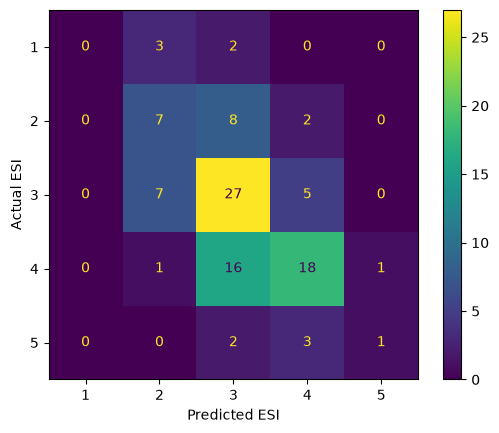

In [154]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ok = eval_df.dropna(subset=["pred_v1"])
y_true = ok["Expert_KTAS"].astype(int)
y_pred = ok["pred_v1"].astype(int)

exact = (y_true == y_pred).mean()
within1 = (y_true - y_pred).abs().le(1).mean()
print(f"exact accuracy:      {exact:.3f}")
print(f"within-one accuracy: {within1:.3f}")

cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4, 5])
ConfusionMatrixDisplay(cm, display_labels=[1, 2, 3, 4, 5]).plot()
plt.xlabel("Predicted ESI")
plt.ylabel("Actual ESI")
plt.show()

Which acuity level does the model predict most often? Does it guess toward the middle (ESI 2–3)?
    It predicts 3 most, followed by 4 and 2 so it is middle leaning. 


In [155]:
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score)

true_high = (y_true <= 2).astype(int)
pred_high = (y_pred <= 2).astype(int)

print("accuracy :", round(accuracy_score(true_high, pred_high), 3))
print("precision:", round(precision_score(true_high, pred_high), 3))
print("recall   :", round(recall_score(true_high, pred_high), 3))
print("f1       :", round(f1_score(true_high, pred_high), 3))

undertriage = ((true_high == 1) & (pred_high == 0)).sum()
overtriage = ((true_high == 0) & (pred_high == 1)).sum()
print("undertriage:", undertriage)
print("overtriage :", overtriage)

accuracy : 0.806
precision: 0.556
recall   : 0.455
f1       : 0.5
undertriage: 12
overtriage : 8


Answer:

1. Which error is more dangerous in an emergency department, and which metric tracks it?
    Undertriage is more dangerous, since a patient might detiorate or die, due to the lack of appropiate care. The undertriage is indicated by a postive result in true_high and negative in pred_high.

In [156]:
wrong = eval_df[(eval_df["Expert_KTAS"] <= 2) & (eval_df["pred_v1"] >= 3)]

for _, row in wrong.head(10).iterrows():
    print(format_patient(row))
    print(f">>> nurse: {row['Expert_KTAS']} | model: {row['pred_v1']}")
    print("-" * 60)

Chief complaint: Motor weakness
Temp: unknown °C
Heart rate: unknown bpm
Respiratory rate: unknown /min
O2 saturation: unknown %
Blood pressure: unknown/unknown mmHg
Pain level: unknown/10
>>> nurse: 1 | model: 3
------------------------------------------------------------
Chief complaint: mental change
Temp: 36.4 °C
Heart rate: 88 bpm
Respiratory rate: unknown /min
O2 saturation: 99 %
Blood pressure: 160/90 mmHg
Pain level: 2/10
>>> nurse: 1 | model: 3
------------------------------------------------------------
Chief complaint: syncope
Temp: 36.3 °C
Heart rate: 71 bpm
Respiratory rate: 20 /min
O2 saturation: 100 %
Blood pressure: 130/80 mmHg
Pain level: unknown/10
>>> nurse: 2 | model: 3
------------------------------------------------------------
Chief complaint: DI, drug intoxication
Temp: 36.9 °C
Heart rate: 87 bpm
Respiratory rate: 18 /min
O2 saturation: unknown %
Blood pressure: 113/55 mmHg
Pain level: unknown/10
>>> nurse: 2 | model: 3
------------------------------------------

In [ ]:
SYSTEM_V2 = SYSTEM_V1 + """
Additional rules:
- Assign level 1 only when the patient requires an immediate life-saving
intervention or has severe physiologic instability.
- In adults, SpO2 < 92%, HR > 120 or < 45, SBP < 90, or RR > 28
must trigger reassessment. If the abnormality is persistent, unexplained,
or accompanied by symptoms or signs of poor perfusion, generally assign
level 2. Assign level 1 only when immediate life-saving intervention is required.
- Active or concerning chest pain, respiratory distress or increasing work
of breathing, acute altered mental status, and clinically significant
overdose or toxic ingestion are high-risk presentations. Generally assign
level 2 unless level 1 criteria are met.
- Do not assign level 4 or 5 when high-risk vital-sign abnormalities are
persistent or clinically significant. Mild, transient, age-appropriate,
or known-baseline abnormalities may be interpreted in clinical context.
- Use age-specific vital-sign thresholds for pediatric patients, and consider
chronic baseline values and medications that may alter vital signs.
"""



run_batch(eval_df, SYSTEM_V2, "pred_v2")

100%|██████████| 103/103 [00:11<00:00,  9.31it/s]

pred_v2: 0 parse failures


In [158]:
wrong = eval_df[(eval_df["Expert_KTAS"] <= 2) & (eval_df["pred_v2"] >= 3)]

for _, row in wrong.head(10).iterrows():
    print(format_patient(row))
    print(f">>> nurse: {row['Expert_KTAS']} | model: {row['pred_v2']}")
    print("-" * 60)

Chief complaint: Motor weakness
Temp: unknown °C
Heart rate: unknown bpm
Respiratory rate: unknown /min
O2 saturation: unknown %
Blood pressure: unknown/unknown mmHg
Pain level: unknown/10
>>> nurse: 1 | model: 5
------------------------------------------------------------
Chief complaint: acute dyspnea
Temp: unknown °C
Heart rate: unknown bpm
Respiratory rate: unknown /min
O2 saturation: unknown %
Blood pressure: unknown/unknown mmHg
Pain level: unknown/10
>>> nurse: 1 | model: 3
------------------------------------------------------------
Chief complaint: mental change
Temp: 36.4 °C
Heart rate: 88 bpm
Respiratory rate: unknown /min
O2 saturation: 99 %
Blood pressure: 160/90 mmHg
Pain level: 2/10
>>> nurse: 1 | model: 3
------------------------------------------------------------
Chief complaint: pain, chest
Temp: 36.3 °C
Heart rate: 57 bpm
Respiratory rate: 18 /min
O2 saturation: unknown %
Blood pressure: 169/89 mmHg
Pain level: 5/10
>>> nurse: 2 | model: 3
--------------------------

v1 → v2: added rule about undertriaging regarding SBP and DBP, added a rule about undertriage regarding eitehr SBP or DBP, temperature rule for high temp. 

Answer:

1. What did you change, and did it fix the cases you targeted without breaking previously correct ones?
    I changed the rules regarding temp, SBP and DBO and it did help with the cases that were specifically targeted using the rules.

In [159]:
examples = (
    pool.drop(eval_df.index)
        .groupby("Expert_KTAS", group_keys=False)
        .sample(n=1, random_state=7)
)

few_shot = []
for _, ex in examples.iterrows():
    few_shot.append({"role": "user", "content": format_patient(ex)})
    few_shot.append({"role": "assistant",
                     "content": json.dumps({"acuity": int(ex["Expert_KTAS"])})})

run_batch(eval_df, SYSTEM_V2, "pred_v3", extra_messages=few_shot)

100%|██████████| 103/103 [00:13<00:00,  7.92it/s]

pred_v3: 0 parse failures


Answer:

1. Why must the few-shot examples come from outside the evaluation sample?
    If the few-shot example came from the sample set, the answers would be exposed. 

In [160]:
results_long = eval_df.melt(
    id_vars=["Expert_KTAS"],
    value_vars=["pred_v1", "pred_v2", "pred_v3"],
    var_name="prompt_version",
    value_name="pred",
).dropna(subset=["pred"])

results_long["pred"] = results_long["pred"].astype(int)
results_long["correct"] = results_long["Expert_KTAS"] == results_long["pred"]

results_long.to_csv("results_long.csv", index=False)
print(results_long.head(123))
print(len(results_long), "rows")

     Expert_KTAS prompt_version  pred  correct
0              1        pred_v1     3    False
1              1        pred_v1     2    False
2              1        pred_v1     2    False
3              1        pred_v1     2    False
4              1        pred_v1     3    False
..           ...            ...   ...      ...
118            2        pred_v2     3    False
119            2        pred_v2     3    False
120            2        pred_v2     3    False
121            2        pred_v2     3    False
122            2        pred_v2     3    False

[123 rows x 4 columns]
309 rows


In [161]:
def summarize(col):
    ok = eval_df.dropna(subset=[col])
    yt = ok["Expert_KTAS"].astype(int)
    yp = ok[col].astype(int)
    th = (yt <= 2).astype(int)
    ph = (yp <= 2).astype(int)
    return {
        "parseable": len(ok),
        "exact_acc": round((yt == yp).mean(), 3),
        "within_one": round((yt - yp).abs().le(1).mean(), 3),
        "high_recall": round(recall_score(th, ph), 3),
        "high_f1": round(f1_score(th, ph), 3),
        "undertriage": int(((th == 1) & (ph == 0)).sum()),
    }

summary = pd.DataFrame({
    "v1": summarize("pred_v1"),
    "v2": summarize("pred_v2"),
    "v3": summarize("pred_v3"),
})
summary.to_csv("summary.csv")
print(summary)

                  v1       v2       v3
parseable    103.000  103.000  103.000
exact_acc      0.515    0.466    0.515
within_one     0.932    0.913    0.951
high_recall    0.455    0.318    0.455
high_f1        0.500    0.368    0.556
undertriage   12.000   15.000   12.000


In [162]:
majority = int(eval_df["Expert_KTAS"].mode()[0])
yt = eval_df["Expert_KTAS"].astype(int)

print("majority level:", majority)
print("baseline exact accuracy:", round((yt == majority).mean(), 3))
print("baseline high-acuity recall:", 1.0 if majority <= 2 else 0.0)

majority level: 3
baseline exact accuracy: 0.379
baseline high-acuity recall: 0.0


Answer:


prompt_version
pred_v1    0.515
pred_v2    0.466
pred_v3    0.515
Name: correct, dtype: float64


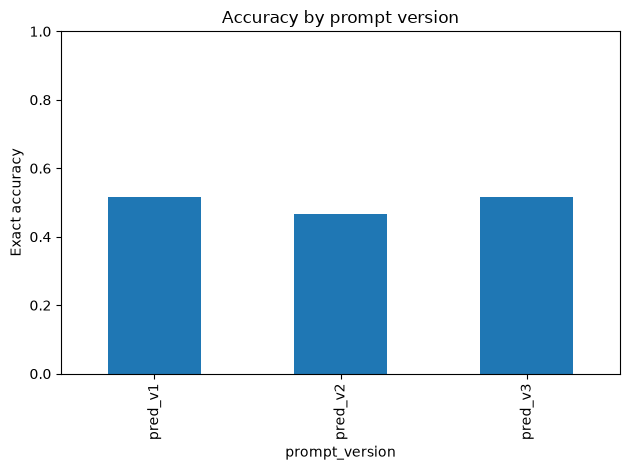

In [163]:
acc_by_version = (
    results_long.groupby("prompt_version")["correct"].mean().round(3)
)
print(acc_by_version)

acc_by_version.plot.bar()
plt.ylabel("Exact accuracy")
plt.ylim(0, 1)
plt.title("Accuracy by prompt version")
plt.tight_layout()
plt.savefig("acc_by_version.png")
plt.show()

Expert_KTAS       1      2      3      4      5
prompt_version                                 
pred_v1         0.0  0.412  0.692  0.500  0.167
pred_v2         0.2  0.235  0.821  0.278  0.167
pred_v3         0.4  0.294  0.821  0.333  0.333


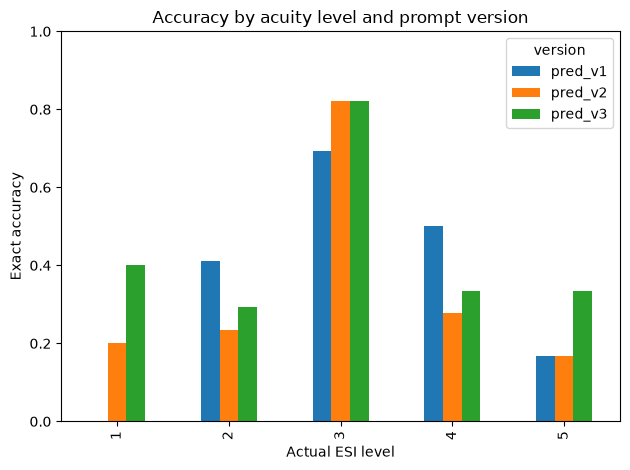

In [164]:
acc_by_level = (
    results_long.groupby(["prompt_version", "Expert_KTAS"])["correct"]
    .mean()
    .unstack()
    .round(3)
)
print(acc_by_level)

acc_by_level.T.plot.bar()
plt.xlabel("Actual ESI level")
plt.ylabel("Exact accuracy")
plt.ylim(0, 1)
plt.title("Accuracy by acuity level and prompt version")
plt.legend(title="version")
plt.tight_layout()
plt.savefig("acc_by_level.png")
plt.show()

In [165]:
SYSTEM_RATIONALE = SYSTEM_V2 + """
Instead, answer with ONLY this JSON format:
{"acuity": <integer 1-5>, "rationale": "<one short sentence>"}
"""